<a href="https://colab.research.google.com/github/pararover/PHY02MJMN01R04_Lab-Manuals/blob/main/Unit_06_SciPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scientific Computations using the `SciPy` Library

* `SciPy` is a open source Python library used for scientific and technical computing.
* `SciPy` provides a wide range of mathematical algorithms and functions that simplify complex computations in physics, engineering, statistics and data analysis.
* `SciPy` has specialized modules for constants, special functions, integration, linear algebra, optimization and more.

Detailed documentation available at: https://docs.scipy.org/doc/scipy-1.8.0/tutorial/general.html

## Importing the `SciPy` library

In [ ]:
import scipy as sc

## Physical constants in `SciPy`

In [ ]:
import scipy.constants as const

In [ ]:
dir(const)

['Avogadro',
 'Boltzmann',
 'Btu',
 'Btu_IT',
 'Btu_th',
 'ConstantWarning',
 'G',
 'Julian_year',
 'N_A',
 'Planck',
 'R',
 'Rydberg',
 'Stefan_Boltzmann',
 'Wien',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_codata',
 '_constants',
 '_obsolete_constants',
 'acre',
 'alpha',
 'angstrom',
 'arcmin',
 'arcminute',
 'arcsec',
 'arcsecond',
 'astronomical_unit',
 'atm',
 'atmosphere',
 'atomic_mass',
 'atto',
 'au',
 'bar',
 'barrel',
 'bbl',
 'blob',
 'c',
 'calorie',
 'calorie_IT',
 'calorie_th',
 'carat',
 'centi',
 'codata',
 'constants',
 'convert_temperature',
 'day',
 'deci',
 'degree',
 'degree_Fahrenheit',
 'deka',
 'dyn',
 'dyne',
 'e',
 'eV',
 'electron_mass',
 'electron_volt',
 'elementary_charge',
 'epsilon_0',
 'erg',
 'exa',
 'exbi',
 'femto',
 'fermi',
 'find',
 'fine_structure',
 'fluid_ounce',
 'fluid_ounce_US',
 'fluid_ounce_imp',
 'foot',
 'g',
 'gallon',
 'gallon_US',
 'g

## S.I. units in `SciPy`

### Metric constants

In [ ]:
print(const.kilo)

1000.0


In [ ]:
print(const.nano)

1e-09


In [ ]:
print(const.femto)

1e-15


In [ ]:
print(const.yotta)

1e+24


### Mass units
Returns the specified unit in **kg**

In [ ]:
const.gram

0.001

In [ ]:
const.lb

0.45359236999999997

In [ ]:
print(const.atomic_mass)
print(const.m_u)
print(const.u)

1.66053906892e-27
1.66053906892e-27
1.66053906892e-27


### Angle units
Returns the specified unit in **rad**

In [ ]:
const.degree

0.017453292519943295

In [ ]:
15 * const.degree

0.2617993877991494

In [ ]:
const.arcmin

0.0002908882086657216

In [ ]:
const.arcsec

4.84813681109536e-06

### Time units
Returns the specified unit in **s**

In [ ]:
const.minute

60.0

In [ ]:
const.hour

3600.0

In [ ]:
const.day

86400.0

In [ ]:
22 * const.year

693792000.0

In [ ]:
const.week

604800.0

In [ ]:
const.year

31536000.0

In [ ]:
const.Julian_year

31557600.0

### Length units
Returns the specified unit in **m**

In [ ]:
const.mile

1609.3439999999998

In [ ]:
const.inch

0.0254

In [ ]:
const.angstrom

1e-10

In [ ]:
const.fermi

1e-15

In [ ]:
const.au

149597870700.0

### Energy units
Returns the specified unit in **J**

In [ ]:
const.eV

1.602176634e-19

In [ ]:
const.calorie

4.184

In [ ]:
const.erg

1e-07

## Special functions in `SciPy`

* The `scipy.special` package is the definition of numerous special functions of mathematical physics.
* Available functions include airy, elliptic, bessel, gamma, beta, hypergeometric, parabolic cylinder, mathieu, spheroidal wave, struve, and kelvin
* Most of these functions can take array arguments and return array results.

Ref: https://docs.scipy.org/doc/scipy-1.8.0/tutorial/special.html

### Bessel functions of real order
Bessel functions are a family of solutions to Bessel's differential equation with real or complex order $\alpha$:
\begin{align*}
  x^2\dfrac{\mathrm{d}^2y}{\mathrm{d}x^2}+x\dfrac{\mathrm{d}y}{\mathrm{d}x}+(x^2-\alpha^2)y=0
\end{align*}

These functions arise in wave propagation problems, such as the vibrational modes of a thin drum head.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

In [ ]:
def drumhead_height(n, k, distance, angle, t):
  kth_zero = special.jn_zeros(n, k)[-1]
  return np.cos(t) * np.cos(n*angle) * special.jn(n, distance*kth_zero)

In [ ]:
theta = np.r_[0:2*np.pi:50j]
radius = np.r_[0:1:50j]

x = np.array([r * np.cos(theta) for r in radius])
y = np.array([r * np.sin(theta) for r in radius])

z = np.array([drumhead_height(1, 1, r, theta, 0.5) for r in radius])

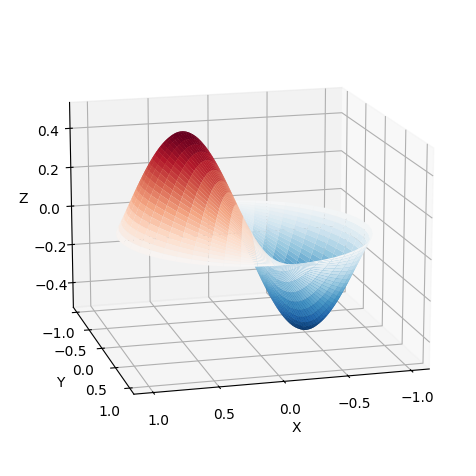

In [ ]:
fig = plt.figure()
ax = fig.add_axes(rect=(0, 0.05, 0.95, 0.95), projection='3d')

ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.view_init(elev=15, azim=75)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xticks(np.arange(-1, 1.1, 0.5))
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_zlabel('Z')

plt.show()

## Integration using `SciPy`

* The `scipy.integrate` sub-package provides several integration techniques including an ordinary differential equation integrator.

### Quadrature integration
* The function `quad` is provided to integrate a function of one variable between two points.
* Example: to integrate a bessel function $J_{2.5}(x)$ along the interval $[0,4.5]$, i.e.
\begin{align*}
  \int\limits_{0}^{4.5}{J_{2.5}(x)\,\mathrm{d}x}
\end{align*}

In [ ]:
import scipy.integrate as integrate
import scipy.special as special

In [ ]:
integrand = lambda x: special.jv(2.5,x)

In [ ]:
type(integrand)

function

In [ ]:
integrate.quad(integrand, 0, 4.5)

(1.1178179380783253, 7.866317216380692e-09)

In [ ]:
integrate.quad(integrand, 0, 4.5)[0]

1.1178179380783253

## Interpolation using `SciPy`

* The `interp1d` class in `scipy.interpolate` is a convenient method to create a function based on fixed data points.
* The interpolated function can be evaluated anywhere within the domain defined by the given data using linear interpolation.

### Linear and cubic interpolation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [ ]:
x = np.linspace(0, 10, num=11, endpoint=True)
y = np.cos(-x**2/9.0)

The data:

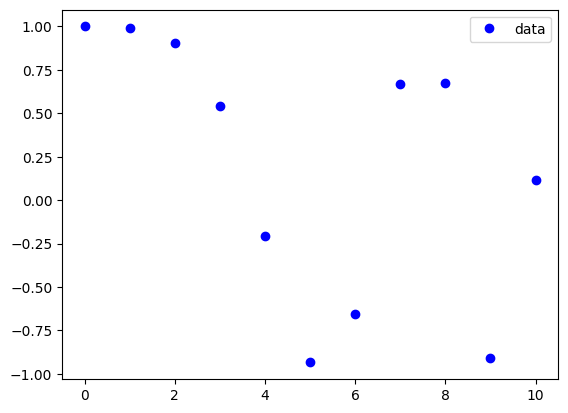

In [ ]:
plt.plot(x, y, 'bo')
plt.legend(['data'], loc='best')
plt.show()

Linear interpolation of data:

In [ ]:
f1 = interp1d(x, y, kind='linear')

In [ ]:
xnew = np.linspace(0, 10, num=41, endpoint=True)
y1 = f1(xnew)

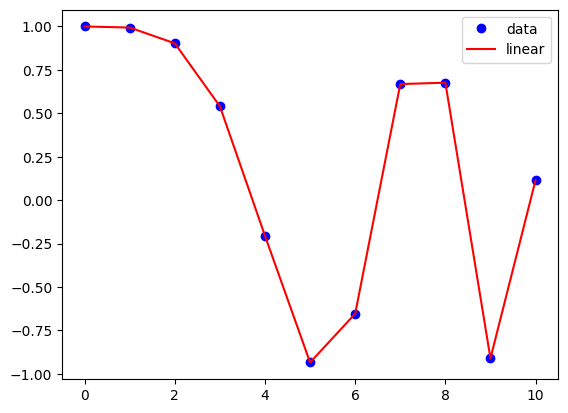

In [ ]:
plt.plot(x, y, 'bo', xnew, y1, 'r-')
plt.legend(['data', 'linear'], loc='best')
plt.show()

Cubic interpolation of data:

In [ ]:
f3 = interp1d(x, y, kind='cubic')

In [ ]:
y3 = f3(xnew)

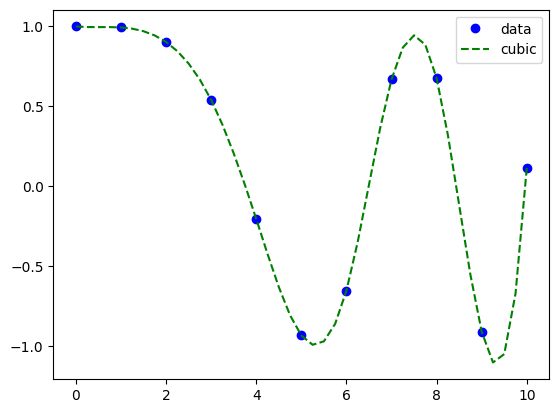

In [ ]:
plt.plot(x, y, 'bo', xnew, y3, 'g--')
plt.legend(['data', 'cubic'], loc='best')
plt.show()

Data and both interpolations:

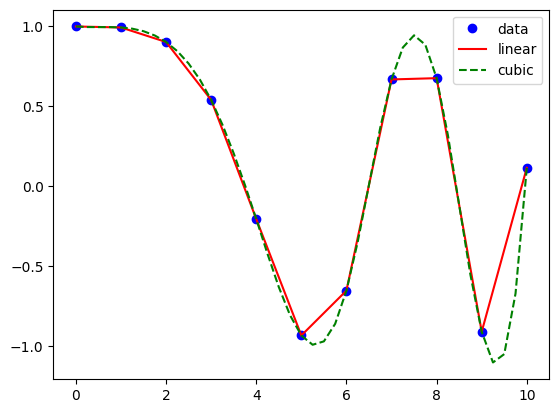

In [ ]:
plt.plot(x, y, 'bo', xnew, y1, 'r-', xnew, y3, 'g--')
plt.legend(['data', 'linear', 'cubic'], loc='best')
plt.show()

## Linear algebra using `SciPy`

* The `scipy.linalg` contains all the functions required for linear algebra routines

### Matrix inverse
To find the inverse of the following matrix:
\begin{align*}
  \mathbf{A}=\begin{bmatrix}
    {1} & {3} & {5} \\
    {2} & {5} & {1} \\
    {2} & {3} & {8}
  \end{bmatrix}
\end{align*}

In [ ]:
import numpy as np
from scipy import linalg

In [ ]:
A = np.array([[1,3,5],
              [2,5,1],
              [2,3,8]])
A

array([[1, 3, 5],
       [2, 5, 1],
       [2, 3, 8]])

In [ ]:
linalg.det(A)

np.float64(-25.000000000000004)

In [ ]:
A_inv = linalg.inv(A)
A_inv

array([[-1.48,  0.36,  0.88],
       [ 0.56,  0.08, -0.36],
       [ 0.16, -0.12,  0.04]])

In [ ]:
A.dot(A_inv)

array([[ 1.00000000e+00, -1.11022302e-16,  4.85722573e-17],
       [ 3.05311332e-16,  1.00000000e+00,  7.63278329e-17],
       [ 2.22044605e-16, -1.11022302e-16,  1.00000000e+00]])

In [ ]:
A_inv.dot(A)

array([[1.00000000e+00, 3.33066907e-16, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 4.44089210e-16],
       [1.38777878e-17, 6.93889390e-18, 1.00000000e+00]])

## System of linear equations
To solve the following system of linear equations:
\begin{align*}
  x+3y+5z&=10 \\
  2x+5y+z&=8 \\
  2x+3y+8&=3
\end{align*}

The system of linear equations can be written as a matrix equation:
$$\mathbf{A}\mathbf{x}=\mathbf{b}$$
where
\begin{align*}
  \mathbf{A}=\begin{bmatrix}
    {1} & {3} & {5} \\
    {2} & {5} & {1} \\
    {2} & {3} & {8}
  \end{bmatrix}\quad\mathbf{b}=\begin{bmatrix}
    {10} \\
    {8} \\
    {3}
  \end{bmatrix}\quad\mathbf{x}=\begin{bmatrix}
    {x} \\
    {y} \\
    {z}
  \end{bmatrix}
\end{align*}
Then we find $\mathbf{x}$ as
\begin{align*}
  \mathbf{x}=\mathbf{A}^{-1}\mathbf{b}
\end{align*}

We can check our solution using the following identity:
$$\mathbf{A}\mathbf{x}-\mathbf{b}=\mathbf{0}$$

In [ ]:
import numpy as np
from scipy import linalg

In [ ]:
A = np.array([[1,3,5],[2,5,1],[2,3,8]])
A

array([[1, 3, 5],
       [2, 5, 1],
       [2, 3, 8]])

In [ ]:
b = np.array([[10], [8], [3]])
b

array([[10],
       [ 8],
       [ 3]])

In [ ]:
A_inv = linalg.inv(A)
x1 = A_inv.dot(b)
x1

array([[-9.28],
       [ 5.16],
       [ 0.76]])

In [ ]:
# Check answer
A.dot(x1) - b

array([[ 0.00000000e+00],
       [-1.77635684e-15],
       [-8.88178420e-16]])

In [ ]:
x2 = np.linalg.solve(A, b)
x2

array([[-9.28],
       [ 5.16],
       [ 0.76]])

In [ ]:
# Check answer
A.dot(x2) - b

array([[ 0.00000000e+00],
       [-1.77635684e-15],
       [-1.77635684e-15]])

## Linear regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
data = np.loadtxt('experimental-data.txt', skiprows=1)

In [ ]:
data

array([[5.0e-01, 1.2e-03],
       [1.0e+00, 1.9e-03],
       [1.5e+00, 3.5e-03],
       [2.0e+00, 3.4e-03],
       [2.5e+00, 5.2e-03],
       [3.0e+00, 6.6e-03],
       [3.5e+00, 6.3e-03],
       [4.0e+00, 8.5e-03],
       [4.5e+00, 9.2e-03],
       [5.0e+00, 9.4e-03]])

In [ ]:
V = data[:,0]
I = data[:,1]

In [ ]:
V

array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])

In [ ]:
I

array([0.0012, 0.0019, 0.0035, 0.0034, 0.0052, 0.0066, 0.0063, 0.0085,
       0.0092, 0.0094])

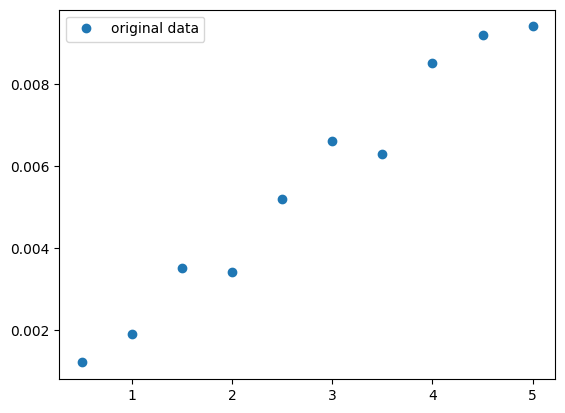

In [ ]:
plt.plot(x, y, 'o', label='original data')

plt.legend()
plt.show()

In [ ]:
reg = stats.linregress(V, I)
reg

LinregressResult(slope=np.float64(0.0019393939393939393), intercept=np.float64(0.00018666666666666658), rvalue=np.float64(0.9866082677629652), pvalue=np.float64(1.3846141166539472e-07), stderr=np.float64(0.00011335763797079501), intercept_stderr=np.float64(0.00035168282312448684))

In [ ]:
1 / reg.slope

np.float64(515.625)

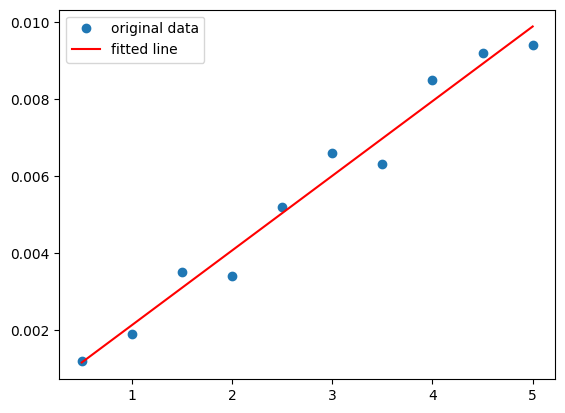

In [ ]:
plt.plot(V, I, 'o', label='original data')
plt.plot(V, reg.slope*V + reg.intercept, 'r', label='fitted line')
plt.legend()
plt.show()